# Level 2 - Task 2 : Classification

In [1]:
# Mount + Import + Load
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score,
                              confusion_matrix, classification_report,
                              roc_curve, auc)
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/drive/MyDrive/Codveda Technologies Data Science task List/Data Set For Task/1) iris.csv')
print("Shape:", df.shape)
print(df.head())
print("\nSpecies Distribution:")
print(df['species'].value_counts())

Mounted at /content/drive
Shape: (150, 5)
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

Species Distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [2]:
# Preprocessing
le = LabelEncoder()
df['species_encoded'] = le.fit_transform(df['species'])

print("Encoding Map:")
for i, cls in enumerate(le.classes_):
    print(f"  {cls} -> {i}")

X = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
y = df['species_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"\nTrain size: {X_train.shape}")
print(f"Test size : {X_test.shape}")

Encoding Map:
  setosa -> 0
  versicolor -> 1
  virginica -> 2

Train size: (120, 4)
Test size : (30, 4)


In [3]:
# Train and Evaluate All Models
results = {}

def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, average='weighted')
    rec  = recall_score(y_te, y_pred, average='weighted')
    f1   = f1_score(y_te, y_pred, average='weighted')
    results[name] = acc
    print(f"\n{'='*45}")
    print(f"Model    : {name}")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_te, y_pred, target_names=le.classes_))
    return model, y_pred

lr_model,  y_pred_lr  = evaluate_model(
    "Logistic Regression",
    LogisticRegression(max_iter=200),
    X_train_s, X_test_s, y_train, y_test
)
rf_model,  y_pred_rf  = evaluate_model(
    "Random Forest",
    RandomForestClassifier(n_estimators=100, random_state=42),
    X_train, X_test, y_train, y_test
)
svm_model, y_pred_svm = evaluate_model(
    "SVM",
    SVC(kernel='rbf', probability=True),
    X_train_s, X_test_s, y_train, y_test
)


Model    : Logistic Regression
Accuracy : 0.9333
Precision: 0.9333
Recall   : 0.9333
F1 Score : 0.9333

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30


Model    : Random Forest
Accuracy : 0.9000
Precision: 0.9024
Recall   : 0.9000
F1 Score : 0.8997

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90

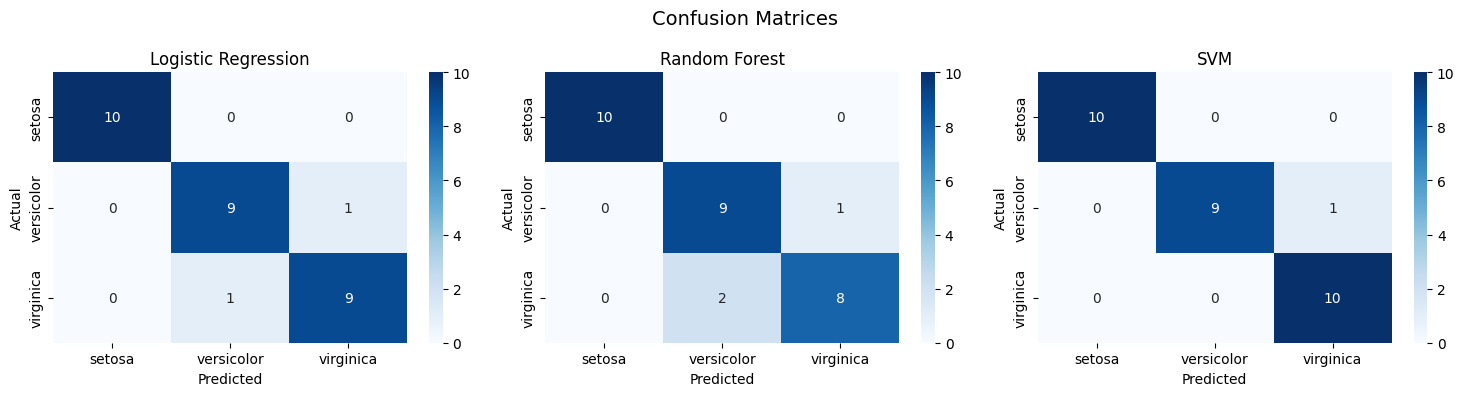

In [4]:
# Confusion Matrix
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, pred) in zip(axes, [
    ("Logistic Regression", y_pred_lr),
    ("Random Forest",       y_pred_rf),
    ("SVM",                 y_pred_svm)
]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                cmap='Blues',
                xticklabels=le.classes_,
                yticklabels=le.classes_)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices', fontsize=14)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/confusion_matrices.png')
plt.show()

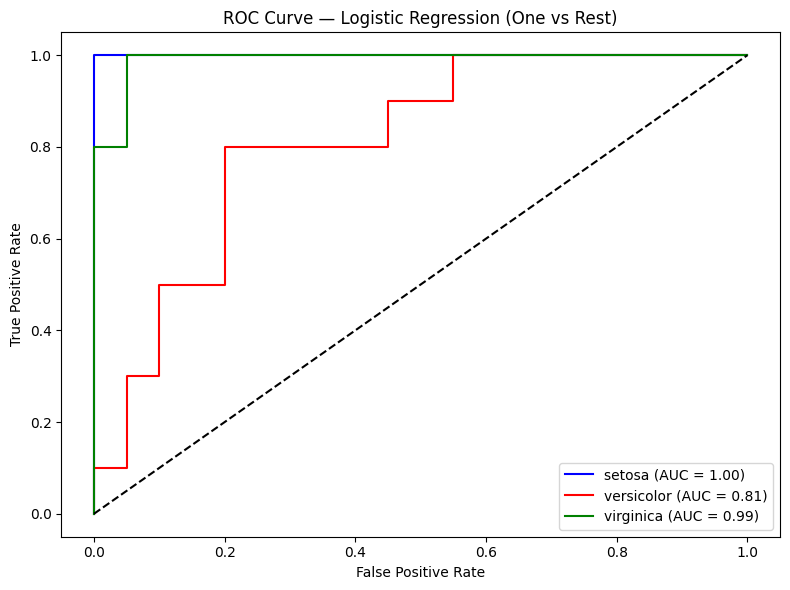

In [5]:
# ROC Curve
y_test_bin  = label_binarize(y_test,  classes=[0, 1, 2])
y_train_bin = label_binarize(y_train, classes=[0, 1, 2])

ovr_clf = OneVsRestClassifier(LogisticRegression(max_iter=200))
ovr_clf.fit(X_train_s, y_train_bin)
y_score = ovr_clf.predict_proba(X_test_s)

plt.figure(figsize=(8, 6))
colors = ['blue', 'red', 'green']
for i, (cls, color) in enumerate(zip(le.classes_, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color,
             label=f'{cls} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Logistic Regression (One vs Rest)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/roc_curve.png')
plt.show()

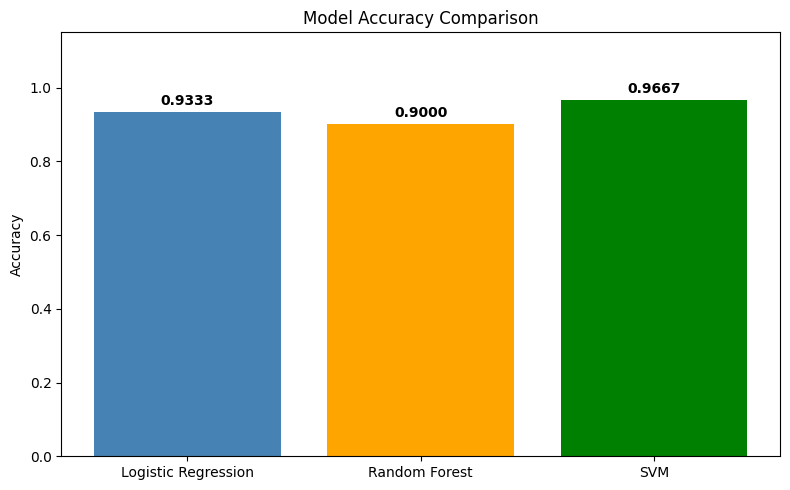

In [6]:
# Model Comparison Chart
plt.figure(figsize=(8, 5))
bars = plt.bar(results.keys(), results.values(),
               color=['steelblue', 'orange', 'green'])
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0, 1.15)
for bar, val in zip(bars, results.values()):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.02,
             f'{val:.4f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/classification_comparison.png')
plt.show()